In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
import os

if os.path.exists("/content/Titanic-Dataset.csv"):
    data_path = "/content/Titanic-Dataset.csv"
else:
    data_path = "../data/Titanic-Dataset.csv"

df = pd.read_csv(data_path)
print("Loaded from:", data_path)
print(df.shape)
df.head()

Loaded from: /content/Titanic-Dataset.csv
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


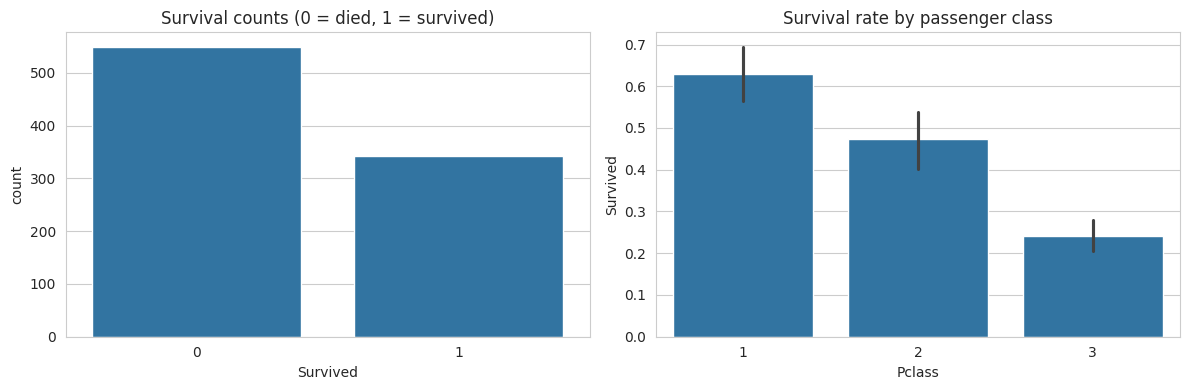

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Survived", ax=axes[0])
axes[0].set_title("Survival counts (0 = died, 1 = survived)")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1])
axes[1].set_title("Survival rate by passenger class")

plt.tight_layout()
plt.show()

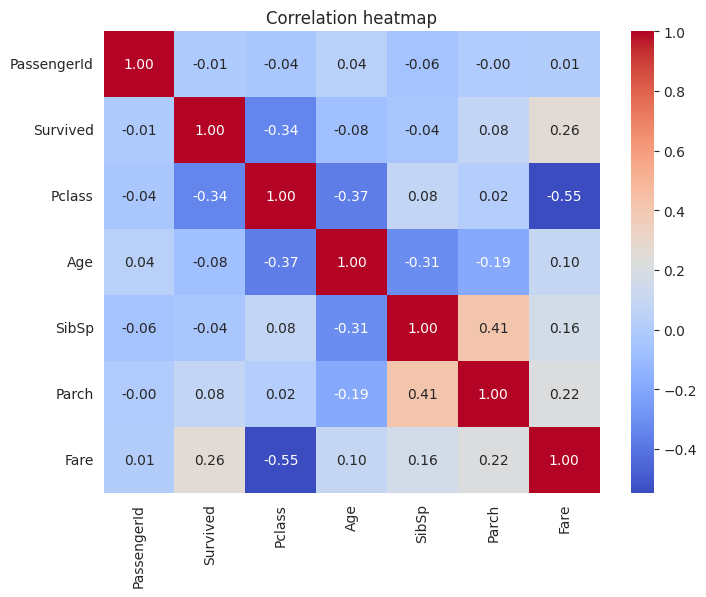

In [7]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

CLEANING N PREPROCESSING

In [8]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
print("duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

le_sex = LabelEncoder()
df["Sex"] = le_sex.fit_transform(df["Sex"])  # female=0, male=1

le_emb = LabelEncoder()
df["Embarked"] = le_emb.fit_transform(df["Embarked"])

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df.head()

duplicates before: 111


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,1,22.0,1,0,7.2500,2,2
1,1,1,0,38.0,1,0,71.2833,0,2
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,2
4,0,3,1,35.0,0,0,8.0500,2,1


Train Test Split + Scaling


In [10]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(624, 8) (156, 8)


Training Models

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    predictions[name] = preds
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    }

results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1
Logistic Regression,0.814103,0.769231,0.781250,0.775194
Decision Tree,0.769231,0.818182,0.562500,0.666667
KNN,0.775641,0.795918,0.609375,0.690265


Comparison visually

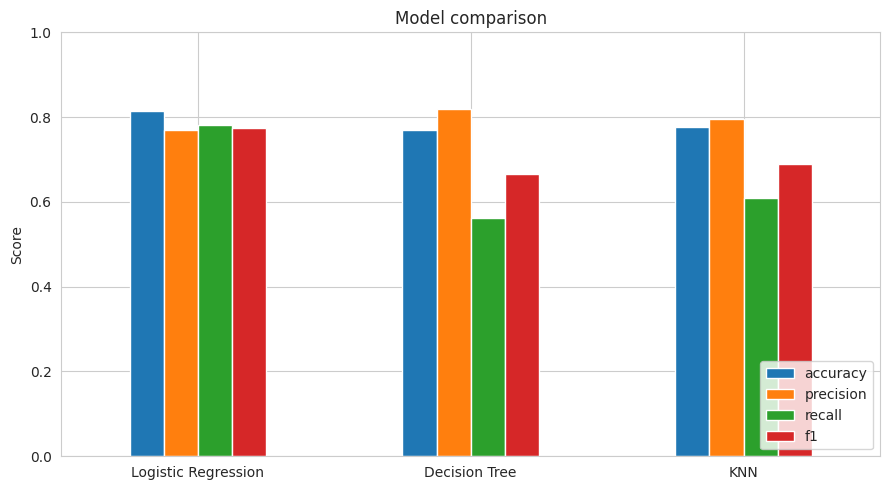

In [16]:
results_df[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

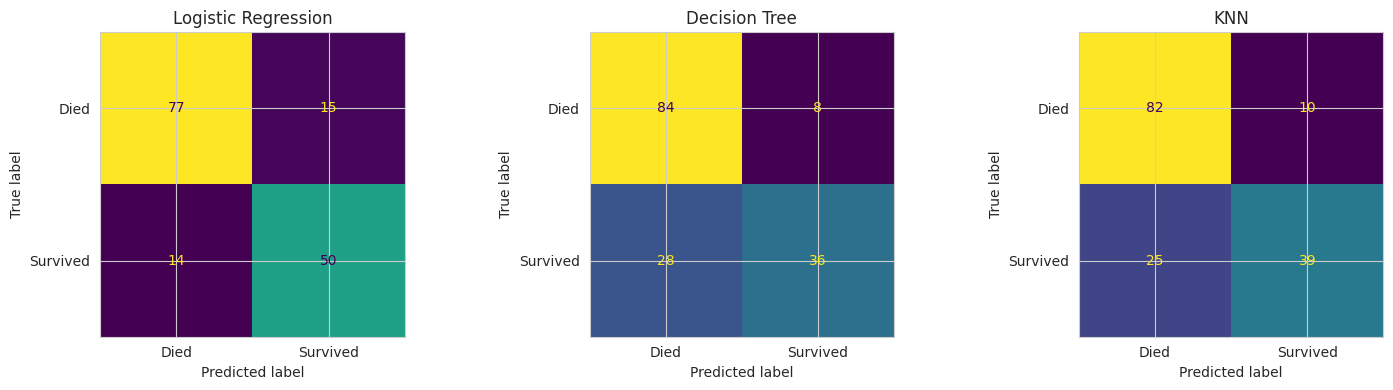

In [17]:
ig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

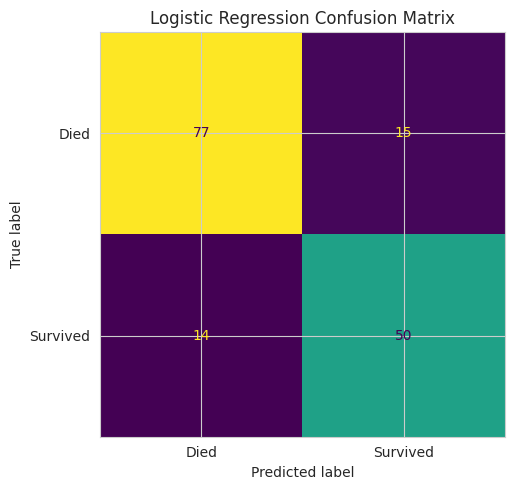

In [18]:
log_reg_preds = predictions['Logistic Regression']
cm_lr = confusion_matrix(y_test, log_reg_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=["Died", "Survived"]).plot(ax=ax, colorbar=False)
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
best_name = results_df["accuracy"].idxmax()
best_model = models[best_name]
print("Best model:", best_name)
print(results_df.loc[best_name])

Best model: Logistic Regression
accuracy     0.814103
precision    0.769231
recall       0.781250
f1           0.775194
Name: Logistic Regression, dtype: float64


In [20]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/trained_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le_sex, "../models/le_sex.pkl")
joblib.dump(le_emb, "../models/le_emb.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")
joblib.dump(results, "../models/results.pkl")

print("Saved model + preprocessing objects to ../models/")

Saved model + preprocessing objects to ../models/
